# 01. Scaled Dot-Product Attention

**Topics covered:** Query, Key, Value · Scaled Dot-Product Attention · Attention Weights

This notebook explains the core building block of the Transformer architecture introduced in *Attention Is All You Need* (Vaswani et al., 2017).

We will:
1. Understand **Query (Q)**, **Key (K)**, and **Value (V)**
2. Derive and implement **Scaled Dot-Product Attention**
3. Visualize and interpret **Attention Weights**
4. Compare a from-scratch implementation with PyTorch’s NN optimized `F.scaled_dot_product_attention`

## 1. Setup & Imports

In [10]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns

torch.manual_seed(42)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")

Using device: cpu
PyTorch version: 2.11.0+cpu


## 2. Query, Key, Value — The Intuition

Think of attention as a **soft information retrieval** system:

| Role | Analogy | Meaning |
|------|---------|--------|
| **Query (Q)** | The question you ask | “What am I looking for?” |
| **Key (K)** | The label / index of stored items | “What information do I contain?” |
| **Value (V)** | The actual content | “What do I return when matched?” |

In self-attention every token produces its own Q, K and V vectors by linear projections of the input embedding:

$$
Q = X W^Q,\quad K = X W^K,\quad V = X W^V
$$

where $X \in \mathbb{R}^{T \times d_{\text{model}}}$ is the sequence of token embeddings and $W^Q, W^K, W^V$ are learnable matrices.

In [11]:
# Toy example: 4 tokens, embedding dimension 6, projection dimension 4
seq_len = 4          # T
d_model = 6          # input embedding size
d_k = 4              # query/key dimension
d_v = 4              # value dimension (often = d_k)

# Simulated input embeddings (batch_size=1 for clarity)
X = torch.randn(1, seq_len, d_model)
print("Input X shape:", X.shape)  # (batch, seq_len, d_model)

# Learnable projection matrices (no bias for simplicity)
W_Q = nn.Linear(d_model, d_k, bias=False)
W_K = nn.Linear(d_model, d_k, bias=False)
W_V = nn.Linear(d_model, d_v, bias=False)

Q = W_Q(X)   # (1, 4, 4)
K = W_K(X)   # (1, 4, 4)
V = W_V(X)   # (1, 4, 4)

print("Q shape:", Q.shape)
print("K shape:", K.shape)
print("V shape:", V.shape)
print("\nQ (first sequence):\n", Q[0].detach().numpy().round(3))

Input X shape: torch.Size([1, 4, 6])
Q shape: torch.Size([1, 4, 4])
K shape: torch.Size([1, 4, 4])
V shape: torch.Size([1, 4, 4])

Q (first sequence):
 [[-0.186  1.194 -0.259  1.053]
 [-0.176  0.279 -0.664  0.556]
 [-0.612 -0.494  0.032 -0.364]
 [-0.222  0.32  -0.649  0.289]]


## 3. The Scaled Dot-Product Attention Formula

$$
\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^\top}{\sqrt{d_k}}\right)V
$$

### Step-by-step breakdown

1. **Scores**  
   $$S = QK^\top \in \mathbb{R}^{T \times T}$$  
   Each entry $S_{ij}$ measures how well query $i$ matches key $j$ (dot-product similarity).

2. **Scaling**  
   $$S_{\text{scaled}} = \frac{S}{\sqrt{d_k}}$$  
   Without scaling, the variance of the dot product grows with $d_k$. Large values push the softmax into a region with near-zero gradients → vanishing gradients. Dividing by $\sqrt{d_k}$ keeps the variance ≈ 1.

3. **Attention Weights**  
   $$A = \text{softmax}(S_{\text{scaled}})$$
   Rows sum to 1 → each query distributes a probability mass over all keys.

4. **Output (Context Vectors)**  
   $$\text{Output} = A V$$
   Weighted sum of the value vectors.

## 4. From-Scratch Implementation

In [12]:
def scaled_dot_product_attention(Q, K, V, mask=None, dropout_p=0.0):
    """
    Compute Scaled Dot-Product Attention.

    Args:
        Q: Queries  (batch, ..., seq_q, d_k)
        K: Keys     (batch, ..., seq_k, d_k)
        V: Values   (batch, ..., seq_k, d_v)
        mask: Optional boolean / additive mask broadcastable to scores
        dropout_p: Dropout probability applied to attention weights

    Returns:
        output:          (batch, ..., seq_q, d_v)
        attention_weights: (batch, ..., seq_q, seq_k)
    """
    d_k = Q.size(-1)

    # 1. Dot-product scores
    scores = torch.matmul(Q, K.transpose(-2, -1))          # (..., seq_q, seq_k)

    # 2. Scale
    scores = scores / math.sqrt(d_k)

    # 3. Optional mask (e.g. causal / padding)
    if mask is not None:
        # Support both boolean masks (True = keep) and additive masks
        if mask.dtype == torch.bool:
            scores = scores.masked_fill(~mask, float("-inf"))
        else:
            scores = scores + mask

    # 4. Softmax → attention weights
    attn_weights = F.softmax(scores, dim=-1)

    # 5. Optional dropout
    if dropout_p > 0.0:
        attn_weights = F.dropout(attn_weights, p=dropout_p)

    # 6. Weighted sum of values
    output = torch.matmul(attn_weights, V)                 # (..., seq_q, d_v)

    return output, attn_weights

In [13]:
# Run the function on our toy tensors
output, attn_weights = scaled_dot_product_attention(Q, K, V)

print("Output shape:          ", output.shape)       # (1, 4, 4)
print("Attention weights shape:", attn_weights.shape) # (1, 4, 4)
print("\nAttention weights (rows sum ≈ 1):")
print(attn_weights[0].detach().numpy().round(3))
print("\nRow sums:", attn_weights[0].sum(dim=-1).detach().numpy().round(5))

Output shape:           torch.Size([1, 4, 4])
Attention weights shape: torch.Size([1, 4, 4])

Attention weights (rows sum ≈ 1):
[[0.692 0.145 0.043 0.12 ]
 [0.408 0.235 0.143 0.214]
 [0.089 0.199 0.469 0.243]
 [0.37  0.236 0.164 0.229]]

Row sums: [1. 1. 1. 1.]


## 5. Visualizing Attention Weights

Each row of the attention matrix shows **how much attention** a query token pays to every key token.

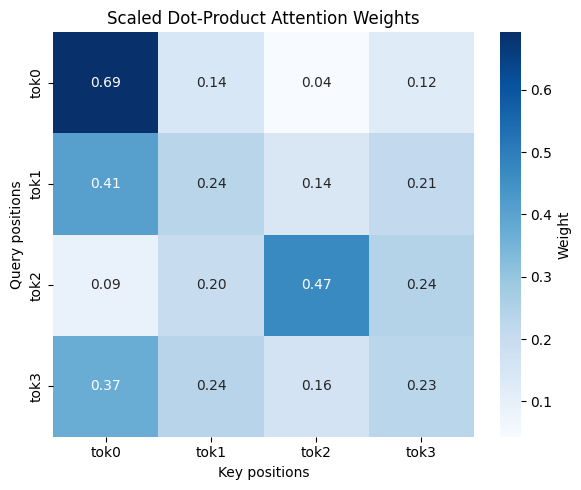

In [14]:
def plot_attention(weights, title="Attention Weights", tokens=None):
    """Heatmap of attention weights (first batch item)."""
    w = weights[0].detach().cpu().numpy()
    plt.figure(figsize=(6, 5))
    sns.heatmap(w, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=tokens or range(w.shape[1]),
                yticklabels=tokens or range(w.shape[0]),
                cbar_kws={"label": "Weight"})
    plt.xlabel("Key positions")
    plt.ylabel("Query positions")
    plt.title(title)
    plt.tight_layout()
    plt.show()

tokens = ["tok0", "tok1", "tok2", "tok3"]
plot_attention(attn_weights, title="Scaled Dot-Product Attention Weights", tokens=tokens)

## 6. Why Do We Scale?  (A Quick Experiment)

Let’s compare the magnitude of raw vs. scaled scores for increasing $d_k$.

In [15]:
def score_statistics(d_k, n_samples=1000):
    q = torch.randn(n_samples, d_k)
    k = torch.randn(n_samples, d_k)
    raw = (q * k).sum(dim=-1)               # dot products
    scaled = raw / math.sqrt(d_k)
    return raw.std().item(), scaled.std().item()

dims = [16, 64, 256, 512, 1024]
print(f"{'d_k':>6} | {'raw std':>10} | {'scaled std':>12}")
print("-" * 34)
for d in dims:
    raw_std, scaled_std = score_statistics(d)
    print(f"{d:6d} | {raw_std:10.3f} | {scaled_std:12.3f}")

   d_k |    raw std |   scaled std
----------------------------------
    16 |      4.117 |        1.029
    64 |      8.267 |        1.033
   256 |     15.997 |        1.000
   512 |     22.832 |        1.009
  1024 |     32.644 |        1.020


Observe that the **raw** standard deviation grows roughly with $\sqrt{d_k}$, while the **scaled** standard deviation stays close to 1. This keeps the softmax in a numerically stable regime.

## 7. Causal (Look-Ahead) Mask

In autoregressive language models a token must not attend to future tokens. We apply a **causal mask** that sets future scores to $-\infty$ before the softmax.

Causal mask:
 tensor([[1, 0, 0, 0],
        [1, 1, 0, 0],
        [1, 1, 1, 0],
        [1, 1, 1, 1]], dtype=torch.int32)


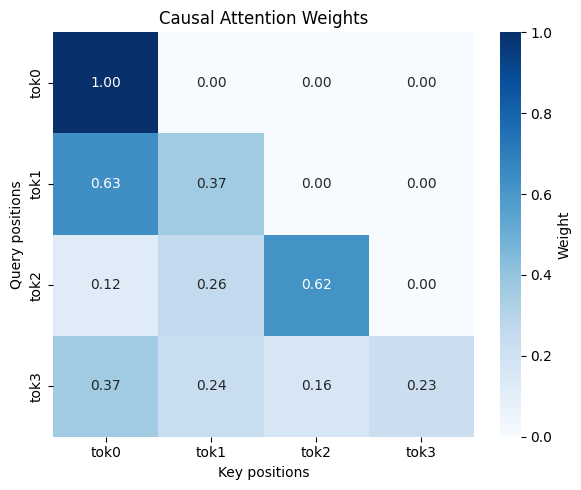


Attention weights with causal mask:
[[1.    0.    0.    0.   ]
 [0.634 0.366 0.    0.   ]
 [0.118 0.263 0.619 0.   ]
 [0.37  0.236 0.164 0.229]]


In [16]:
def causal_mask(seq_len, device=None):
    """Lower-triangular boolean mask (True = attend)."""
    return torch.tril(torch.ones(seq_len, seq_len, dtype=torch.bool, device=device))

mask = causal_mask(seq_len)
print("Causal mask:\n", mask.int())

output_causal, attn_causal = scaled_dot_product_attention(Q, K, V, mask=mask)

plot_attention(attn_causal, title="Causal Attention Weights", tokens=tokens)
print("\nAttention weights with causal mask:")
print(attn_causal[0].detach().numpy().round(3))

## 8. PyTorch’s Optimized Implementation

From PyTorch 2.0 onward you can use the highly optimized fused kernel:

In [17]:
# Same tensors – native API
out_native = F.scaled_dot_product_attention(Q, K, V)

# With causal mask (is_causal=True is more efficient than a full mask)
out_native_causal = F.scaled_dot_product_attention(Q, K, V, is_causal=True)

print("From-scratch vs native (max abs diff):",
      (output - out_native).abs().max().item())
print("Causal from-scratch vs native (max abs diff):",
      (output_causal - out_native_causal).abs().max().item())

From-scratch vs native (max abs diff): 1.4901161193847656e-08
Causal from-scratch vs native (max abs diff): 5.960464477539063e-08


## 9. Complete Self-Attention Module

Putting everything together into a reusable `nn.Module`.

In [18]:
class ScaledDotProductAttention(nn.Module):
    """
    Self-attention layer that projects input into Q, K, V
    and applies scaled dot-product attention.
    """
    def __init__(self, d_model, d_k=None, d_v=None, dropout=0.1):
        super().__init__()
        self.d_k = d_k or d_model
        self.d_v = d_v or d_model

        self.W_Q = nn.Linear(d_model, self.d_k, bias=False)
        self.W_K = nn.Linear(d_model, self.d_k, bias=False)
        self.W_V = nn.Linear(d_model, self.d_v, bias=False)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        """
        Args:
            x:    (batch, seq_len, d_model)
            mask: optional causal / padding mask
        Returns:
            context: (batch, seq_len, d_v)
            attn:    (batch, seq_len, seq_len)
        """
        Q = self.W_Q(x)
        K = self.W_K(x)
        V = self.W_V(x)

        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)

        if mask is not None:
            if mask.dtype == torch.bool:
                scores = scores.masked_fill(~mask, float("-inf"))
            else:
                scores = scores + mask

        attn = F.softmax(scores, dim=-1)
        attn = self.dropout(attn)
        context = torch.matmul(attn, V)
        return context, attn


# Quick test
attn_layer = ScaledDotProductAttention(d_model=d_model, d_k=d_k, d_v=d_v)
context, weights = attn_layer(X)
print("Context shape:", context.shape)
print("Weights shape:", weights.shape)

Context shape: torch.Size([1, 4, 4])
Weights shape: torch.Size([1, 4, 4])


## 10. Summary

| Concept | Description |
|---------|-------------|
| **Query** | “What am I looking for?” – projected from the current token |
| **Key** | “What do I contain?” – projected from every token |
| **Value** | “What information do I provide?” – the content that is mixed |
| **Scores** | $QK^\top$ – similarity between every query and every key |
| **Scaling** | Divide by $\sqrt{d_k}$ to keep variance stable |
| **Attention Weights** | Softmax of scaled scores – probability distribution over keys |
| **Output** | Weighted sum of Values – context-aware representation |

### Key take-aways
- Scaled Dot-Product Attention is the fundamental operation inside every Transformer attention head.
- The scaling factor $\sqrt{d_k}$ is crucial for stable training when $d_k$ is large.
- Attention weights are interpretable: they show which tokens the model focuses on.
- In practice prefer `F.scaled_dot_product_attention` (or FlashAttention) for speed and memory efficiency.

---

**Next steps** (typical follow-up notebooks):
- Multi-Head Attention
- Positional encodings
- Full Transformer Encoder / Decoder block